# Product Clustering — KMeans baseline

Fits the clustering model used by `src/clustering/cluster.py` / the API, inspects cluster contents, and produces `datasets/clusters_with_reviews.csv` — required by the summarization endpoint.

In [1]:
import sys
sys.path.append('../..')

import pandas as pd
from src.clustering.cluster import fit_clusters

df = pd.read_csv('../../datasets/merged_reviews.csv')
print(f'{len(df)} reviews loaded')

59743 reviews loaded


In [2]:
products = df[['product_id', 'product_title']].drop_duplicates(subset=['product_title']).reset_index(drop=True)

## Fit and persist the model
Saves to `models/B_clustering/kmeans_model.pkl` (used by the API's `assign_cluster()`). Set `n_clusters` based on the elbow plot from `01_EDA.ipynb` (default 5, within the 4-6 range).

In [34]:
N_CLUSTERS = 5
products = products.dropna(subset=['product_title']).reset_index(drop=True)
cluster_ids, kmeans = fit_clusters(products['product_title'].astype(str).tolist(), n_clusters=N_CLUSTERS)
products['cluster_id'] = cluster_ids
products.to_csv('../../datasets/clusters.csv', index=False)
products['cluster_id'].value_counts().sort_index()

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

cluster_id
0     8
1    14
2    25
3    13
4    11
Name: count, dtype: int64

## Inspect cluster contents
Manually review these samples to assign a human-readable label per cluster.

In [37]:
for cid in sorted(products['cluster_id'].unique()):
    print(f'\n--- Cluster {cid} ({(products.cluster_id == cid).sum()} products) ---')
    for t in products[products.cluster_id == cid]['product_title'].head(8):
        print('  -', t)


--- Cluster 0 (8 products) ---
  - Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black
  - Amazon 9W Power
  - Amazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black
  - Coconut Water Red Tea 16.5 Oz (pack of 12)
  - Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen
  - Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker
  - Amazon
  - Amazon Tap Smart Assistant Alexaenabled (black) Brand New

--- Cluster 1 (14 products) ---
  - All-New Fire HD 8 Tablet
  - Fire HD 8 Tablet with Alexa
  - Fire Tablet
  - Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue
  - Fire Kids Edition Tablet
  - Amazon Fire Kids Edition Tablet
  - Amazon Fire Hd 8 8in Tablet 16gb Black B018szt3bk 6th Gen (2016) Android
  - Amazon Fire Hd 10 Tablet

--- Cluster 2 (25 products) ---
  - Kindle Oasis E-reader with Leather Charging Cover - Merlot
  - Amazon Kindle Lighted Leather Cover
  - Kindle Keyboard
  - Amazon 5W USB Official OEM Charger and Power Adapter for Fire T

## Assign labels
After inspecting the printed samples above, edit this dict to reflect what each cluster actually contains, then it gets written to `models/B_clustering/cluster_labels.json` (used by the API).

In [39]:
import json

cluster_labels = {
    '0': 'Speakers & Power Accessories',
    '1': 'Fire Tablets',
    '2': 'E-Readers & Accessories',
    '3': 'Echo & Smart Speakers',
    '4': 'Fire TV & Accessories',
}

with open('../../models/B_clustering/cluster_labels.json', 'w') as f:
    json.dump(cluster_labels, f, indent=2)
print('Saved cluster_labels.json')

Saved cluster_labels.json


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

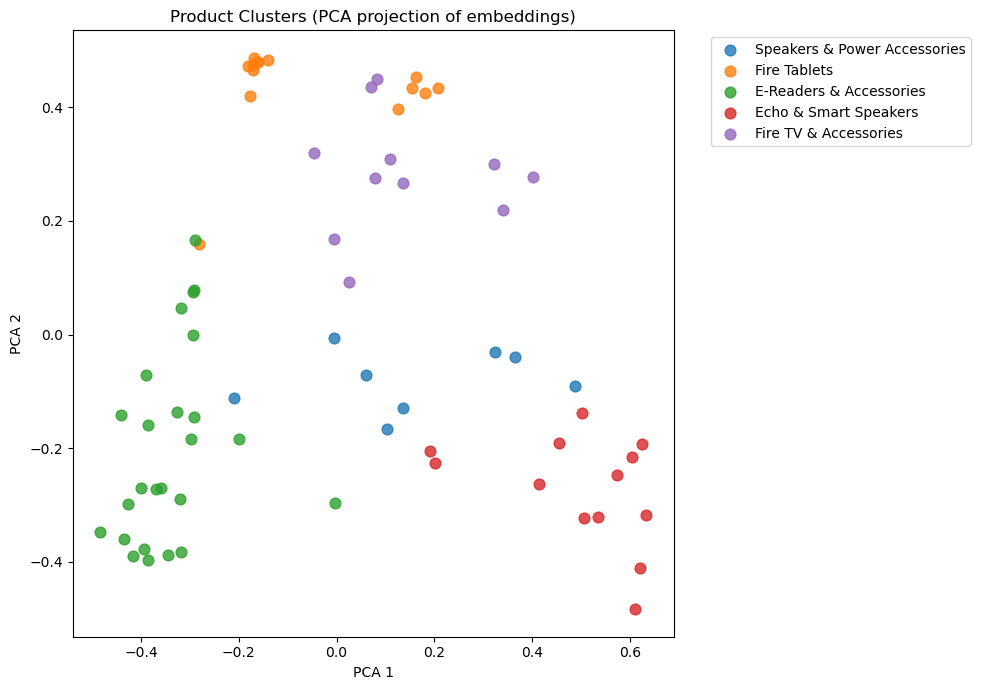

In [40]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = embedder.encode(products['product_title'].astype(str).tolist(), show_progress_bar=True)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce embeddings to 2D for visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)
products['x'] = coords[:, 0]
products['y'] = coords[:, 1]

# Load your assigned labels so the legend shows names, not just numbers
import json
with open('../../models/B_clustering/cluster_labels.json') as f:
    cluster_labels = json.load(f)
products['cluster_name'] = products['cluster_id'].astype(str).map(cluster_labels)

plt.figure(figsize=(10, 7))
for cid in sorted(products['cluster_id'].unique()):
    subset = products[products['cluster_id'] == cid]
    plt.scatter(subset['x'], subset['y'], label=cluster_labels.get(str(cid), f'Cluster {cid}'), s=60, alpha=0.8)

plt.title('Product Clusters (PCA projection of embeddings)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Build `clusters_with_reviews.csv`
Join review-level data with each product's cluster_id. This is the file `api/routers/summarization.py` reads to build recommendation articles per category.

In [42]:
# Join on product_title (the trusted identifier), not product_id -
# see notebooks/00_data_merging_and_cleaning.ipynb for why product_id is unreliable.
products['cluster_name'] = products['cluster_id'].astype(str).map(cluster_labels)

reviews_with_clusters = df.merge(
    products[['product_title', 'cluster_name']], on='product_title', how='inner'
)
reviews_with_clusters = reviews_with_clusters.rename(columns={'cluster_name': 'cluster_id'})
reviews_with_clusters.to_csv('../../datasets/clusters_with_reviews.csv', index=False)
print(f'Saved {len(reviews_with_clusters)} rows to datasets/clusters_with_reviews.csv')
reviews_with_clusters.head()

Saved 52984 rows to datasets/clusters_with_reviews.csv


,product_id,product_title,brand,primaryCategories,review_text,review_title,star_rating,cluster_id
0,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,This product so far has not disappointed. My c...,Kindle,5.0,Fire Tablets
1,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,great for beginner or experienced person. Boug...,very fast,5.0,Fire Tablets
2,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,5.0,Fire Tablets
3,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,I've had my Fire HD 8 two weeks now and I love...,Good!!!,4.0,Fire Tablets
4,AVqkIhwDv8e3D1O-lebb,All-New Fire HD 8 Tablet,Amazon,NaN,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,5.0,Fire Tablets


## Sanity check
Confirm every cluster has enough reviews to generate a meaningful article (top-3 + worst product).

In [43]:
reviews_with_clusters.groupby('cluster_id').size().rename('review_count')

cluster_id
E-Readers & Accessories          4874
Echo & Smart Speakers            3938
Fire TV & Accessories            2571
Fire Tablets                    29280
Speakers & Power Accessories    12321
Name: review_count, dtype: int64